6.Data Analytics III

1.Implement Simple Naïve Bayes classification algorithm using Python/R on iris.csv dataset.

2.Compute Confusion matrix to find TP, FP, TN, FN, Accuracy, Error rate, Precision, Recall
on the given dataset

In [3]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

# Set the style for plots
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
# Using sklearn's built-in iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to pandas DataFrame for easier manipulation
df = pd.DataFrame(X, columns=feature_names)
df['species'] = [iris.target_names[i] for i in y]

# Display the first few rows of the dataset
print("First 5 rows of the iris dataset:")
print(df.head())

# Alternatively, if you want to load from a CSV file:
# df = pd.read_csv('iris.csv')

First 5 rows of the iris dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [5]:
# Display summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Count of each species
print("\nCount of each species:")
print(df['species'].value_counts())


Summary Statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Count of each species:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


<Figure size 1200x1000 with 0 Axes>

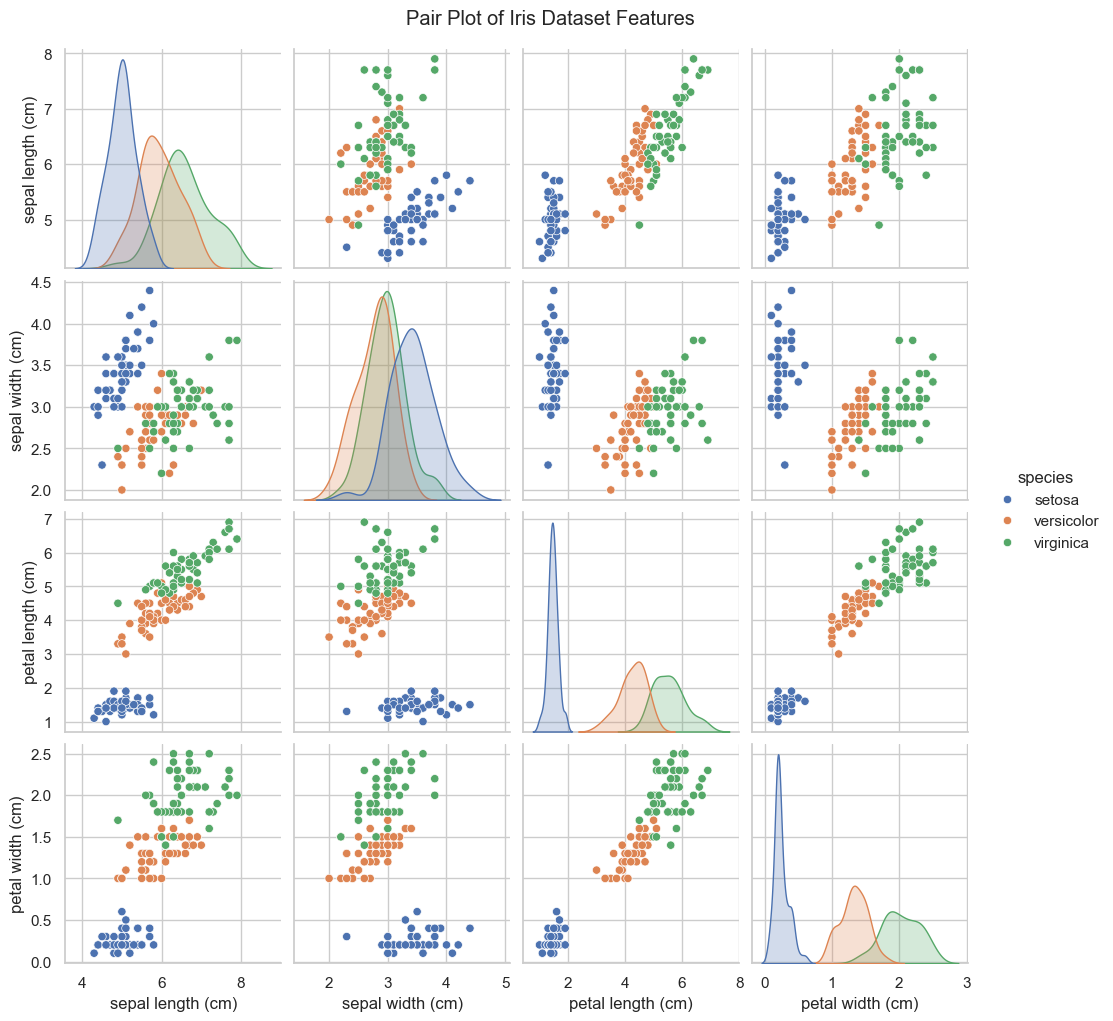

In [6]:
# Create a pair plot to visualize the relationships between features
plt.figure(figsize=(12, 10))
sns.pairplot(df, hue='species', height=2.5)
plt.suptitle("Pair Plot of Iris Dataset Features", y=1.02)
plt.show()

In [7]:
# Extract features and target variable
X = df.drop('species', axis=1).values
y_labels = df['species'].values

# Encode target variable (if not already encoded)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 120 samples
Testing set size: 30 samples


In [8]:
# Initialize the Gaussian Naive Bayes classifier
nb_model = GaussianNB()

# Train the model on the training data
nb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = nb_model.predict(X_test)

In [9]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


In [10]:
# Function to compute TP, FP, TN, FN for each class in a multiclass setting
def compute_metrics(cm, class_idx):
    tp = cm[class_idx, class_idx]
    fp = cm[:, class_idx].sum() - tp
    fn = cm[class_idx, :].sum() - tp
    tn = cm.sum() - (tp + fp + fn)
    
    # Calculate additional metrics
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    error_rate = 1 - accuracy
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    return {
        'TP': tp, 
        'FP': fp, 
        'TN': tn, 
        'FN': fn,
        'Accuracy': accuracy,
        'Error Rate': error_rate,
        'Precision': precision,
        'Recall': recall
    }

In [11]:
# Calculate metrics for each class
metrics_by_class = {}
for i, class_name in enumerate(target_names):
    metrics_by_class[class_name] = compute_metrics(cm, i)

# Display the metrics for each class
print("\nPerformance Metrics by Class:")
metrics_df = pd.DataFrame(metrics_by_class).T
print(metrics_df)

# Calculate overall accuracy
overall_accuracy = np.sum(np.diag(cm)) / np.sum(cm)
print(f"\nOverall Accuracy: {overall_accuracy:.4f}")
print(f"Overall Error Rate: {1 - overall_accuracy:.4f}")

# Generate a classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


Performance Metrics by Class:
              TP   FP    TN   FN  Accuracy  Error Rate  Precision  Recall
setosa      10.0  0.0  20.0  0.0  1.000000    0.000000   1.000000     1.0
versicolor   9.0  0.0  20.0  1.0  0.966667    0.033333   1.000000     0.9
virginica   10.0  1.0  19.0  0.0  0.966667    0.033333   0.909091     1.0

Overall Accuracy: 0.9667
Overall Error Rate: 0.0333

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



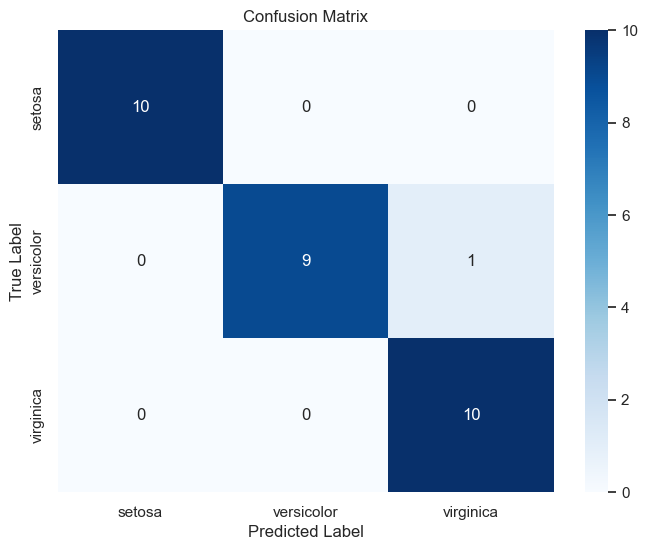

In [13]:
# Visualize the confusion matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()